# Iteration 1: Data Loading and Exploratory Data Analysis

**Project:** Lifestyle Predictors of Type 2 Diabetes  
**Dataset:** BRFSS 2015 (Kaggle)  
**Goal:** Load the data, perform EDA, understand the structure and distributions

## 0. Install Dependencies

In [1]:
%pip install shap imbalanced-learn kaggle pyarrow -q



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
if Path.cwd().name == 'notebooks':
    BASE_DIR = Path.cwd().parent
else:
    BASE_DIR = Path.cwd()
DATA_RAW = BASE_DIR / 'data' / 'raw'
DATA_PROC = BASE_DIR / 'data' / 'processed'
FIGURES = BASE_DIR / 'outputs' / 'figures'
for p in [DATA_RAW, DATA_PROC, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = {'0': '#4A90D9', '1': '#E05C5C'}
print('Libraries loaded')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

Библиотеки загружены
   pandas  3.0.2
   numpy   2.4.4


## 2. Load Data from Kaggle

In [3]:
csv_path = DATA_RAW / 'diabetes_binary_health_indicators_BRFSS2015.csv'
if not csv_path.exists():
    print('Downloading dataset from Kaggle...')
    result = subprocess.run(
        ['kaggle', 'datasets', 'download',
         '-d', 'alexteboul/diabetes-health-indicators-dataset',
         '-p', str(DATA_RAW), '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print('Error:', result.stderr)
        print('Make sure ~/.kaggle/kaggle.json is configured')
    else:
        print('Dataset downloaded!')
else:
    print(f'File already exists: {csv_path.name}')

Файл уже есть: diabetes_binary_health_indicators_BRFSS2015.csv


In [4]:
df = pd.read_csv(csv_path)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Датасет загружен: 253,680 строк × 22 столбцов


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0


## 3. Dataset Structure

In [5]:
print('Data types and non-null counts')
df.info()

Типы данных и ненулевые значения
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 n

In [6]:
print('Missing values')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

Пропущенные значения
Пропущенных значений нет


In [7]:
print('Descriptive statistics')
df.describe().round(2)

Описательная статистика


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


## 4. Target Analysis: Class Balance

Распределение таргета
Нет диабета (0): 218,334  (86.1%)
Диабет/преддиабет (1): 35,346  (13.9%)
Соотношение классов: 6.2:1


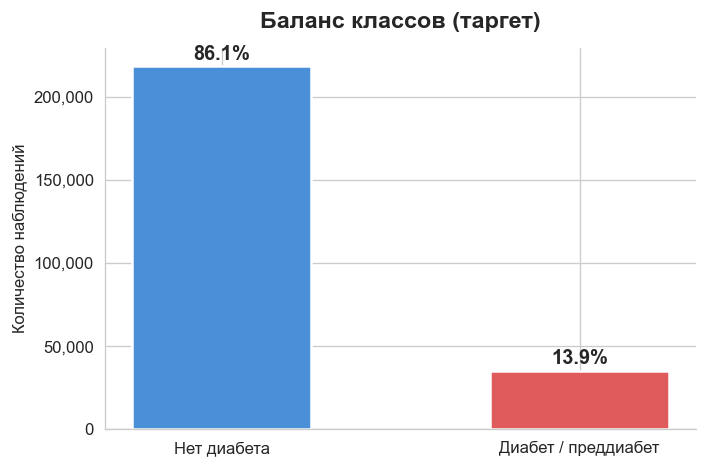

Сохранено: outputs/figures/class_balance.png


In [8]:
target_counts = df['Diabetes_binary'].value_counts()
target_pct = df['Diabetes_binary'].value_counts(normalize=True) * 100
print('Target distribution')
print(f"No diabetes (0): {target_counts[0]:,}  ({target_pct[0]:.1f}%)")
print(f"Diabetes/prediabetes (1): {target_counts[1]:,}  ({target_pct[1]:.1f}%)")
print(f"Class ratio: {target_counts[0]/target_counts[1]:.1f}:1")
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['No Diabetes', 'Diabetes / Prediabetes'],
    target_counts.values,
    color=['#4A90D9', '#E05C5C'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Class Balance (Target)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of observations')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / 'class_balance.png', bbox_inches='tight')
plt.show()
print(f'Saved: outputs/figures/class_balance.png')

## 5. Distribution of Continuous Features

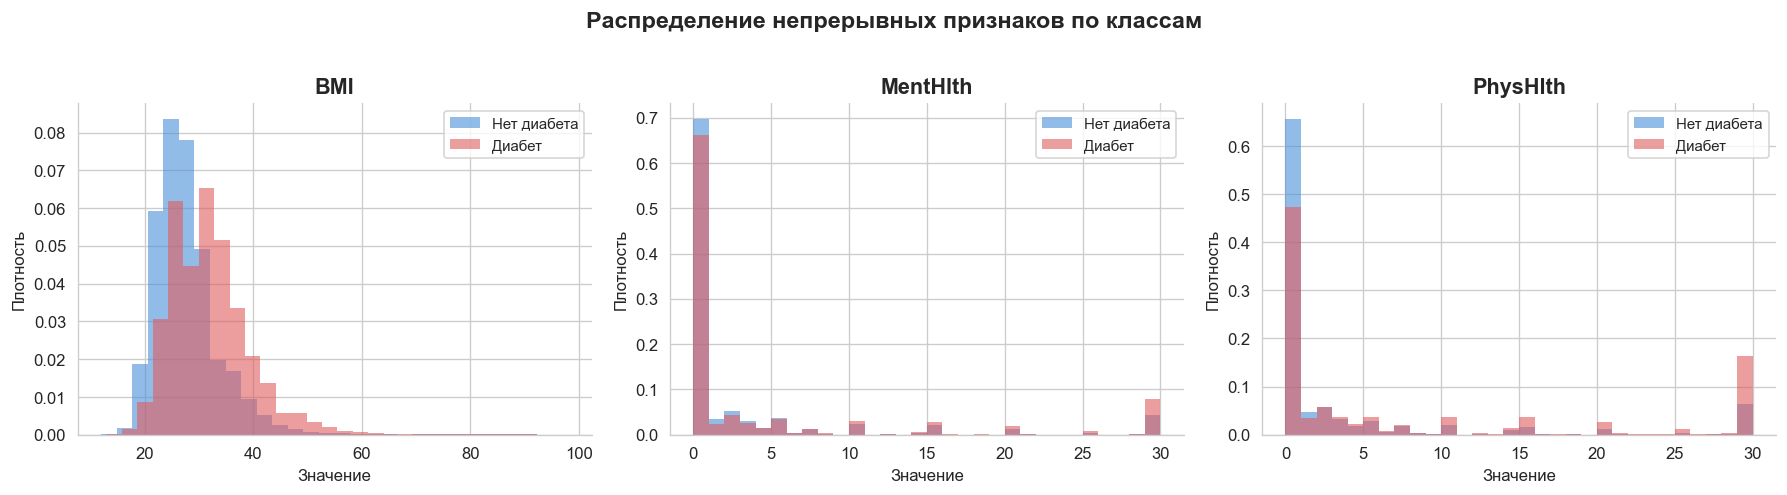

In [9]:
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']
labels = {0: 'No Diabetes', 1: 'Диабет'}
colors = {0: '#4A90D9', 1: '#E05C5C'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, continuous_features):
    for cls in [0, 1]:
        vals = df[df['Diabetes_binary'] == cls][feat]
        ax.hist(vals, bins=30, alpha=0.6, color=colors[cls],
                label=labels[cls], density=True, edgecolor='none')
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Distribution of Continuous Features by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'continuous_distributions.png', bbox_inches='tight')
plt.show()

## 6. Binary Features: Diabetes Rate per Group

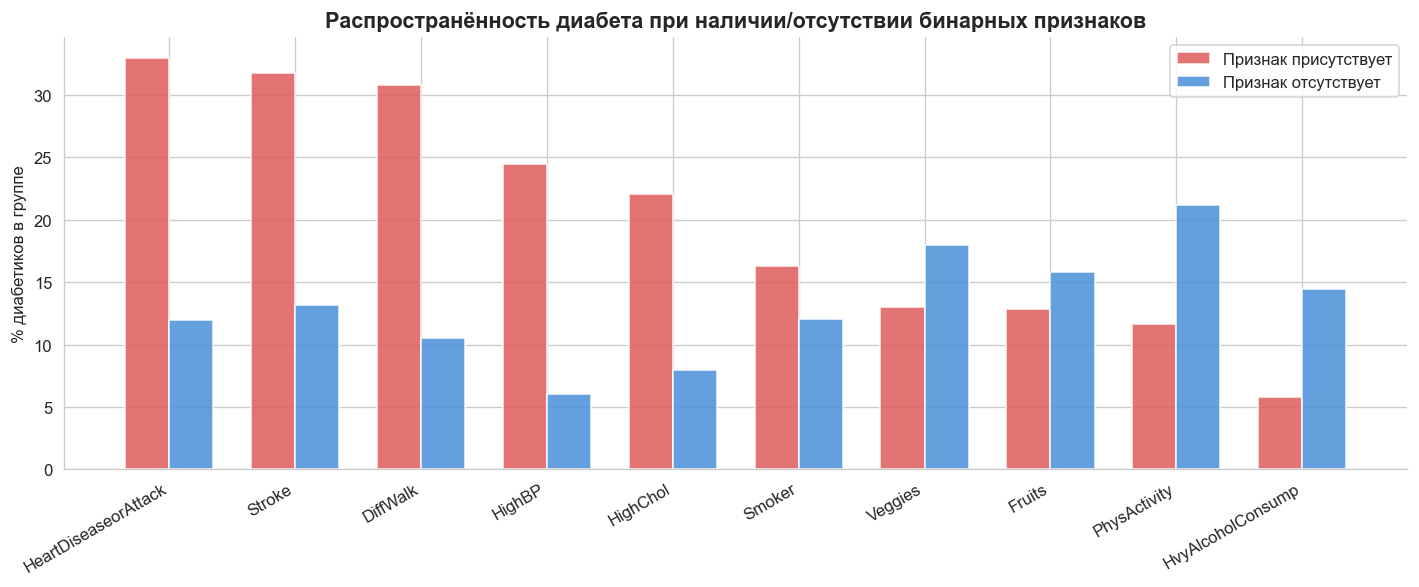


Топ-факторов риска (при наличии признака)
HeartDiseaseorAttack    33.0
Stroke                  31.8
DiffWalk                30.7
HighBP                  24.4
HighChol                22.0
Smoker                  16.3
Veggies                 13.0
Fruits                  12.9
PhysActivity            11.6
HvyAlcoholConsump        5.8


In [10]:
binary_features = [
    'HighBP', 'HighChol', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
    'Veggies', 'HvyAlcoholConsump', 'DiffWalk'
]
diabetes_rates = {}
for feat in binary_features:
    rate_yes = df[df[feat] == 1]['Diabetes_binary'].mean() * 100
    rate_no  = df[df[feat] == 0]['Diabetes_binary'].mean() * 100
    diabetes_rates[feat] = {'Present (1)': rate_yes, 'Absent (0)': rate_no}
rates_df = pd.DataFrame(diabetes_rates).T.sort_values('Present (1)', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rates_df))
width = 0.35
bars1 = ax.bar(x - width/2, rates_df['Present (1)'], width, label='Feature present', color='#E05C5C', alpha=0.85)
bars2 = ax.bar(x + width/2, rates_df['Absent (0)'],  width, label='Feature absent',  color='#4A90D9', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(rates_df.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% diabetics in group')
ax.set_title('Diabetes prevalence by presence/absence of binary features', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / 'binary_features_diabetes_rate.png', bbox_inches='tight')
plt.show()
print('\nТоп-факторов риска (при наличии признака)')
print(rates_df['Present (1)'].round(1).to_string())

## 7. Correlation Matrix

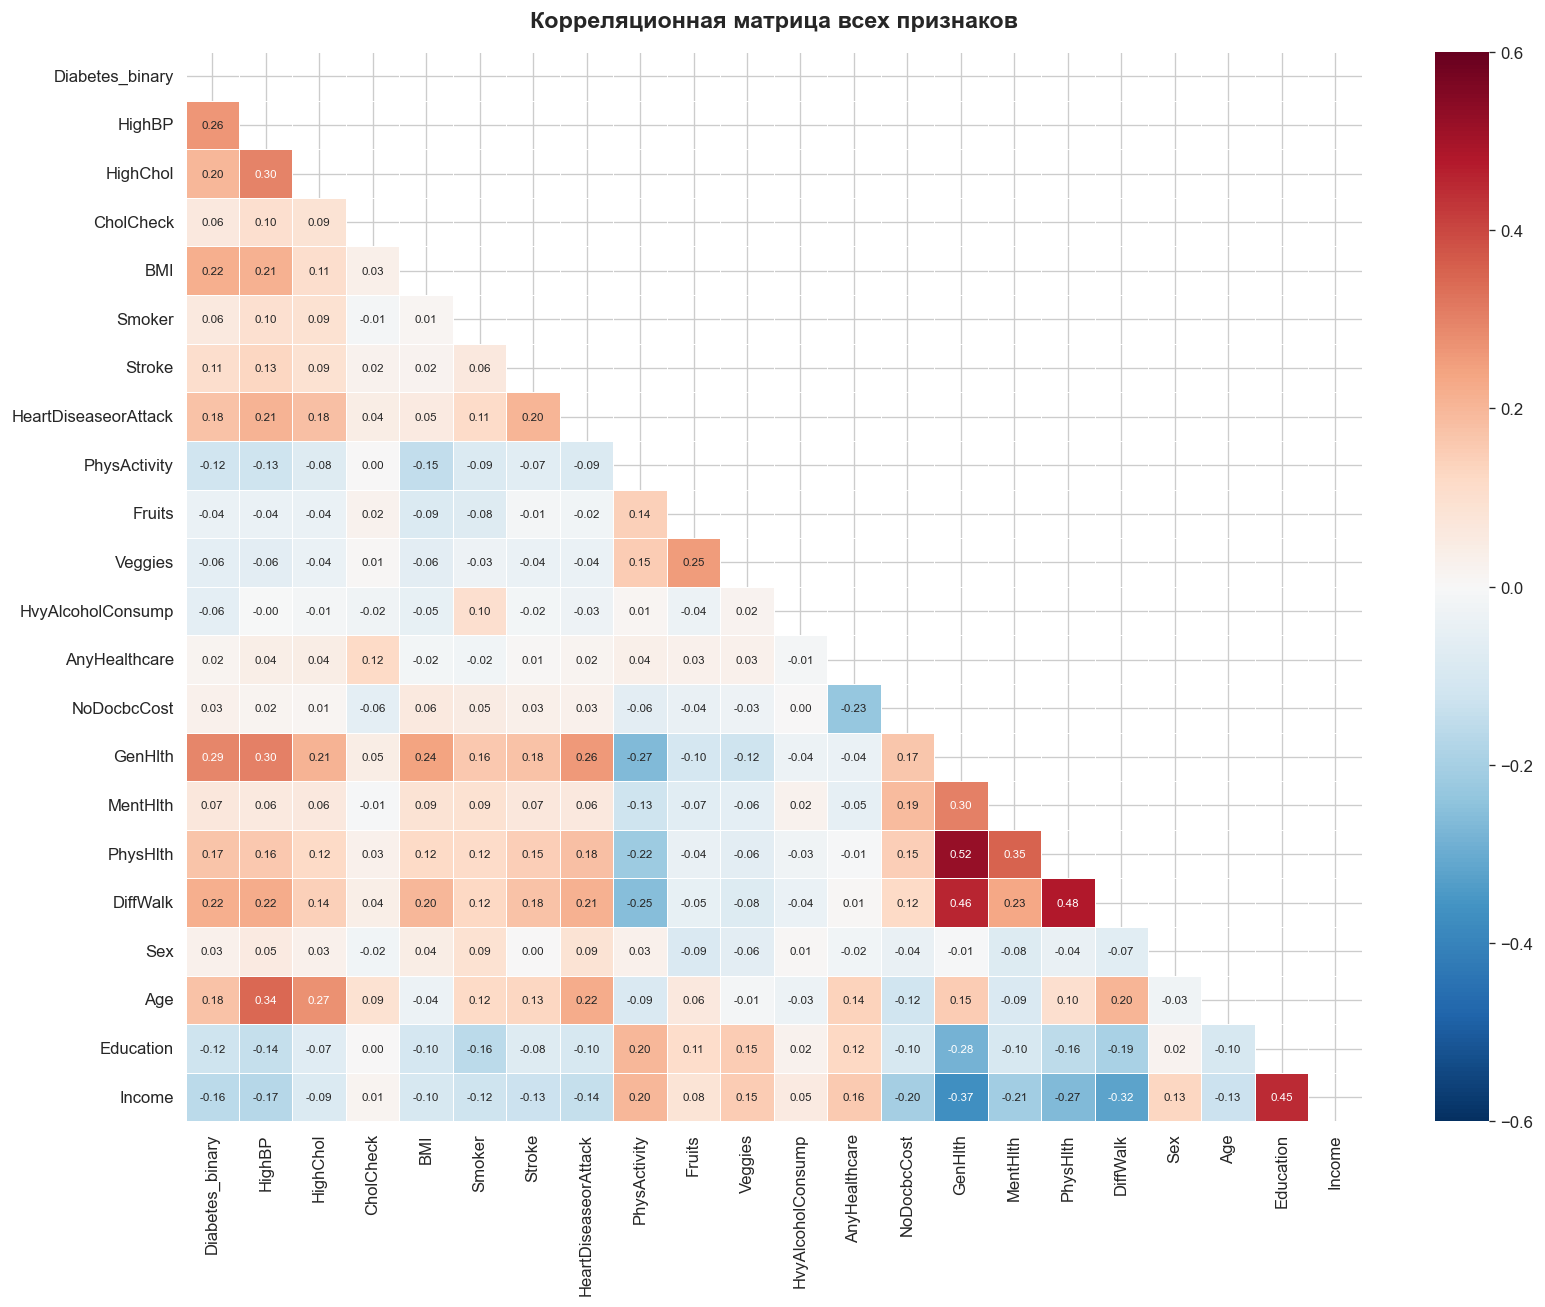

In [11]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix of All Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

## 8. Feature Correlation with Target

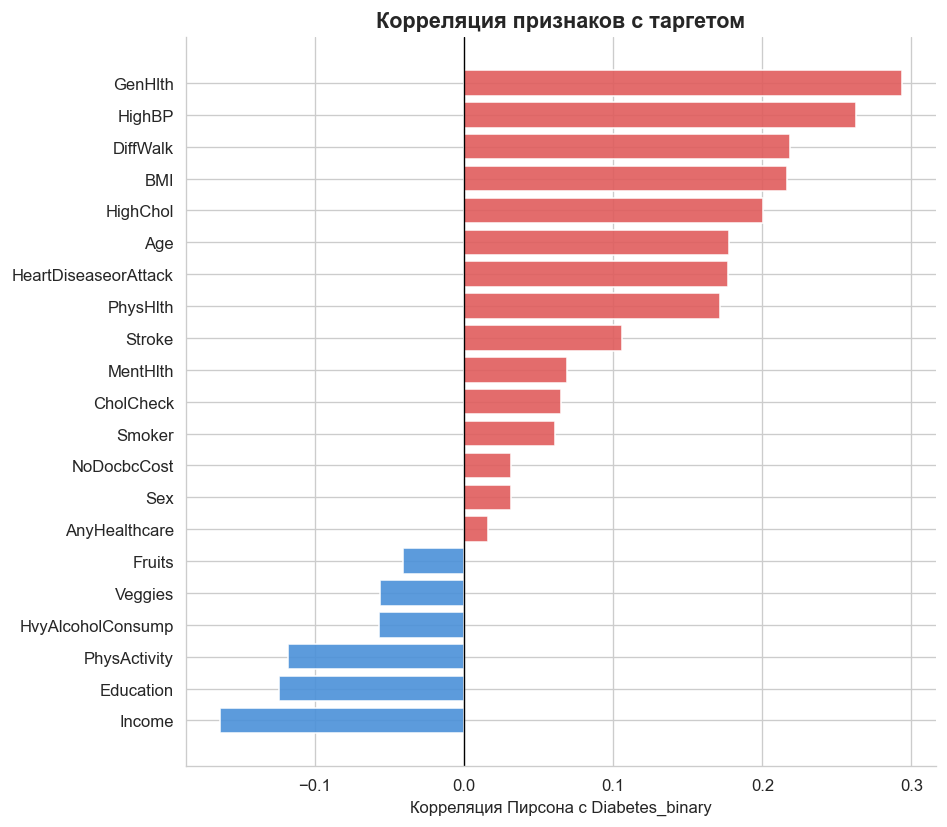


ТОП-5 признаков (положит. корреляция)
HighChol    0.200
BMI         0.217
DiffWalk    0.218
HighBP      0.263
GenHlth     0.294

ТОП-5 признаков (отрицат. корреляция)
Income              -0.164
Education           -0.124
PhysActivity        -0.118
HvyAlcoholConsump   -0.057
Veggies             -0.057


In [12]:
target_corr = df.corr(numeric_only=True)['Diabetes_binary'].drop('Diabetes_binary').sort_values()
colors_bar = ['#E05C5C' if v > 0 else '#4A90D9' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white', alpha=0.9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with Diabetes_binary')
ax.set_title('Feature correlation with target', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / 'target_correlations.png', bbox_inches='tight')
plt.show()
print('\nТОП-5 признаков (положит. корреляция)')
print(target_corr.tail(5).round(3).to_string())
print('\nТОП-5 признаков (отрицат. корреляция)')
print(target_corr.head(5).round(3).to_string())

## 9. Demographic Breakdown: Age and Sex

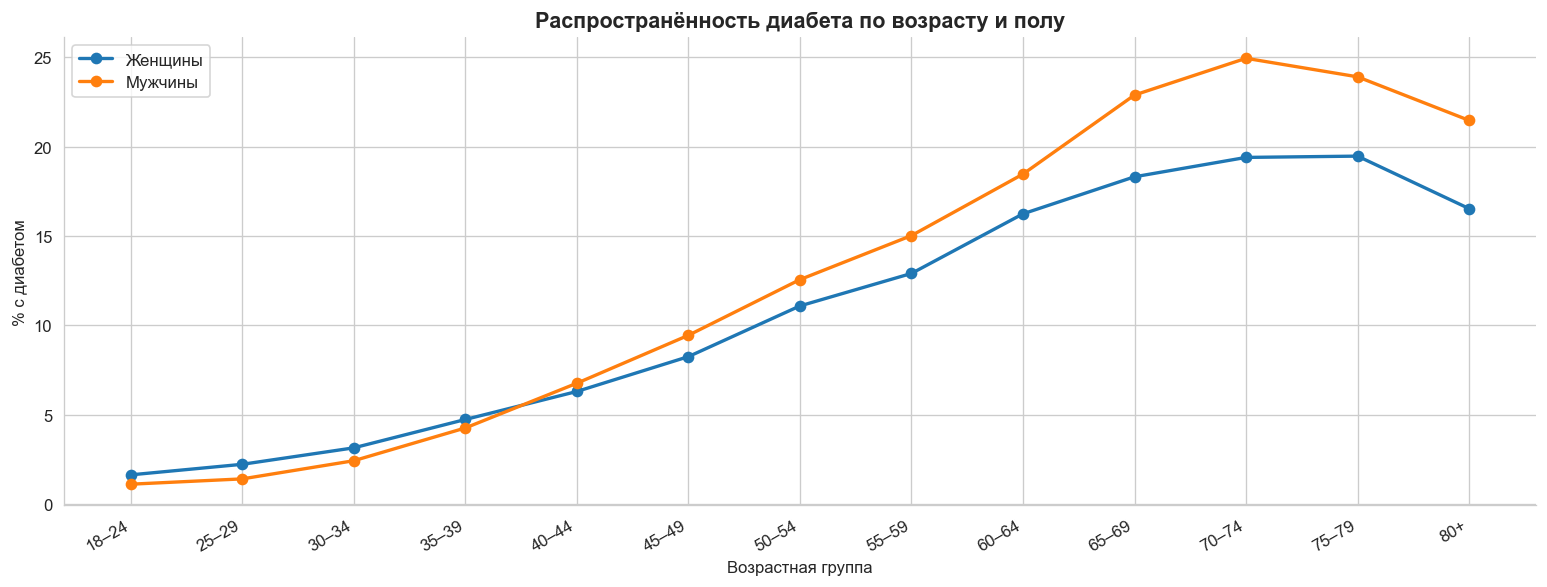

In [13]:
age_labels = {
    1: '18–24', 2: '25–29', 3: '30–34', 4: '35–39',
    5: '40–44', 6: '45–49', 7: '50–54', 8: '55–59',
    9: '60–64', 10: '65–69', 11: '70–74', 12: '75–79', 13: '80+'
}
df['Age_label'] = df['Age'].map(age_labels)
df['Sex_label'] = df['Sex'].map({0: 'Female', 1: 'Male'})

age_diab = df.groupby(['Age_label', 'Sex_label'])['Diabetes_binary'].mean() * 100
age_diab = age_diab.reset_index()
age_diab.columns = ['Age', 'Sex', 'Diabetes rate, %']
age_order = list(age_labels.values())

fig, ax = plt.subplots(figsize=(13, 5))
for sex, grp in age_diab.groupby('Sex'):
    grp_sorted = grp.set_index('Age').reindex(age_order).reset_index()
    ax.plot(grp_sorted['Age'], grp_sorted['Diabetes rate, %'],
            marker='o', label=sex, linewidth=2)

ax.set_xlabel('Age group')
ax.set_ylabel('% with diabetes')
ax.set_title('Diabetes prevalence by age and sex', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / 'diabetes_by_age_sex.png', bbox_inches='tight')
plt.show()

## 10. BMI — Key Feature

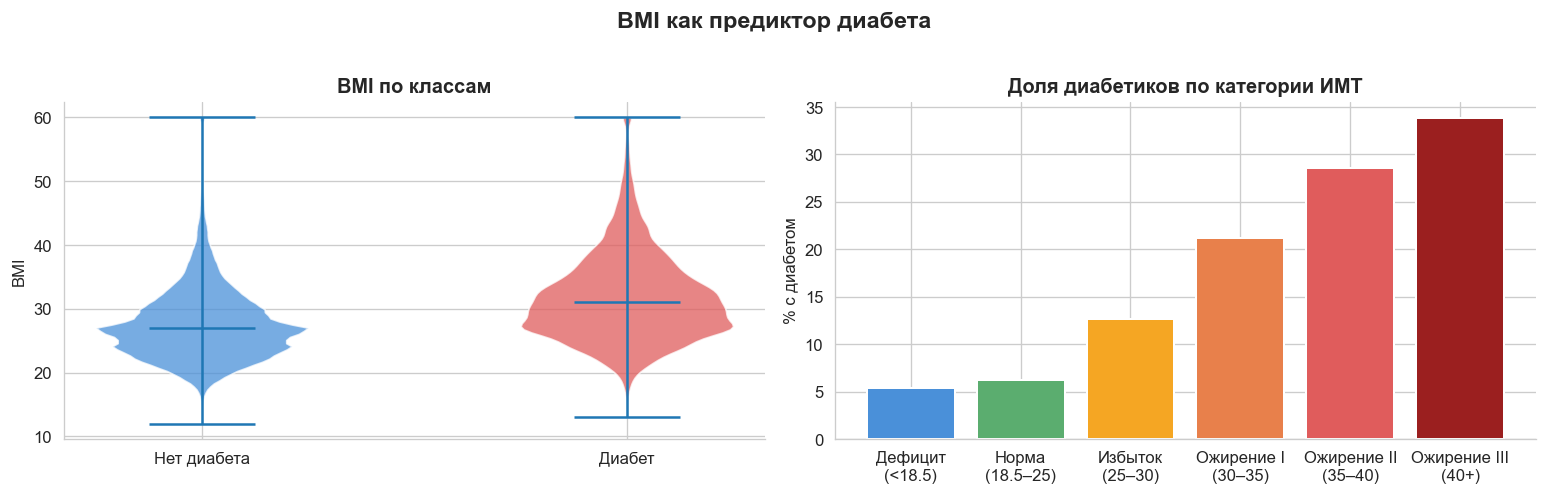

Медианный BMI по классам
                 median   mean
Diabetes_binary               
0.0                27.0  27.81
1.0                31.0  31.94


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
data_plot = [
    df[df['Diabetes_binary'] == 0]['BMI'].clip(upper=60),
    df[df['Diabetes_binary'] == 1]['BMI'].clip(upper=60)
]
parts = axes[0].violinplot(data_plot, positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], ['#4A90D9', '#E05C5C']):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Diabetes', 'Диабет'])
axes[0].set_ylabel('BMI')
axes[0].set_title('BMI by Class', fontsize=12, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)
bmi_bins = [0, 18.5, 25, 30, 35, 40, 100]
bmi_labels = ['Underweight\n(<18.5)', 'Normal\n(18.5–25)', 'Overweight\n(25–30)',
              'Obese I\n(30–35)', 'Obese II\n(35–40)', 'Obese III\n(40+)']
df['BMI_cat'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)
bmi_diab = df.groupby('BMI_cat', observed=True)['Diabetes_binary'].mean() * 100
axes[1].bar(bmi_diab.index, bmi_diab.values,
            color=['#4A90D9', '#5BAD6F', '#F5A623', '#E8804B', '#E05C5C', '#9B1F1F'],
            edgecolor='white', linewidth=1.2)
axes[1].set_ylabel('% with diabetes')
axes[1].set_title('Diabetes rate by BMI category', fontsize=12, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)
plt.suptitle('BMI as a Diabetes Predictor', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'bmi_analysis.png', bbox_inches='tight')
plt.show()
print('Median BMI by class')
print(df.groupby('Diabetes_binary')['BMI'].agg(['median', 'mean']).round(2))

## 11. Save Intermediate Dataset

In [15]:
df_save = df.drop(columns=['Age_label', 'Sex_label', 'BMI_cat'])
df_save.to_parquet(DATA_PROC / 'brfss2015_raw.parquet', index=False)
print(f'Data saved to data/processed/brfss2015_raw.parquet')
print(f'   Shape: {df_save.shape}')

Данные сохранены в data/processed/brfss2015_raw.parquet
   Размер: (253680, 22)


## 12. Summary of Iteration 1

### Key Findings

Fill in after running:

```
1. Class balance: ~??% diabetic -> SMOTE or class_weight needed
2. Missing values: none
3. Top predictors (by correlation): ...
4. BMI: median for diabetics ?? vs ?? for healthy
5. Age: peak diabetes rate in group ...
```

### Next Step → Iteration 2

- Handle class imbalance (SMOTE)
- Normalize BMI, MentHlth, PhysHlth
- Train/val/test split (70/15/15)
- Logistic Regression — baseline model